In [1]:
from pandas import DataFrame

df = DataFrame()
df['t'] = [x for x in range(10)]
print(df)

   t
0  0
1  1
2  2
3  3
4  4
5  5
6  6
7  7
8  8
9  9


In [2]:
df['t-1'] = df['t'].shift(1)
print(df)

   t  t-1
0  0  NaN
1  1  0.0
2  2  1.0
3  3  2.0
4  4  3.0
5  5  4.0
6  6  5.0
7  7  6.0
8  8  7.0
9  9  8.0


In [3]:
df['t+1'] = df['t'].shift(-1)
print(df)

   t  t-1  t+1
0  0  NaN  1.0
1  1  0.0  2.0
2  2  1.0  3.0
3  3  2.0  4.0
4  4  3.0  5.0
5  5  4.0  6.0
6  6  5.0  7.0
7  7  6.0  8.0
8  8  7.0  9.0
9  9  8.0  NaN


In [17]:
from pandas import concat

def series_to_supervise(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()

    #input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]

    #forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += ['var%d(t)' % (j + 1) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]

    #put it all together
    agg = concat(cols, axis=1)
    agg.columns = names

    #drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [12]:
values = [x for x in range(10)]
data = series_to_supervise(values)
print(data)

   var1(t-1)  var1(t)
1        0.0        1
2        1.0        2
3        2.0        3
4        3.0        4
5        4.0        5
6        5.0        6
7        6.0        7
8        7.0        8
9        8.0        9


In [13]:
values = [x for x in range(10)]
data = series_to_supervise(values, 2, 2)
print(data)

   var1(t-2)  var1(t-1)  var1(t)  var1(t+1)
2        0.0        1.0        2        3.0
3        1.0        2.0        3        4.0
4        2.0        3.0        4        5.0
5        3.0        4.0        5        6.0
6        4.0        5.0        6        7.0
7        5.0        6.0        7        8.0
8        6.0        7.0        8        9.0


In [14]:
raw = DataFrame()
raw['ob1'] = [x for x in range(10)]
raw['ob2'] = [x for x in range(50, 60)]
values = raw.values

In [15]:
print(raw)

   ob1  ob2
0    0   50
1    1   51
2    2   52
3    3   53
4    4   54
5    5   55
6    6   56
7    7   57
8    8   58
9    9   59


In [18]:
raw = DataFrame()
raw['ob1'] = [x for x in range(10)]
raw['ob2'] = [x for x in range(50, 60)]

values = raw.values
data = series_to_supervise(values)
print(data)

   var1(t-1)  var2(t-1)  var1(t)  var2(t)
1        0.0       50.0        1       51
2        1.0       51.0        2       52
3        2.0       52.0        3       53
4        3.0       53.0        4       54
5        4.0       54.0        5       55
6        5.0       55.0        6       56
7        6.0       56.0        7       57
8        7.0       57.0        8       58
9        8.0       58.0        9       59


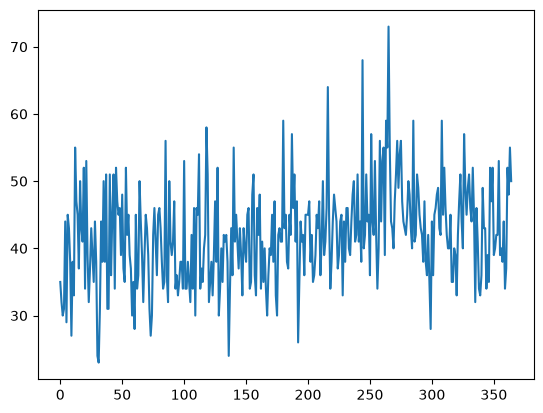

In [20]:
#load and plot the time series dataset
from pandas import read_csv
from matplotlib import pyplot

#load dataset
series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
values = series.values

#plot dataset
pyplot.plot(values)
pyplot.show()


In [21]:
#forecast monthly births with random forest

from numpy import asarray
from pandas import read_csv
from pandas import DataFrame
from pandas import concat

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot

In [22]:
#transdform a time series dataset into a supervised learning dataset

def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols = list()

    #input sequence (t-n, ... t+n)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(-i))

    #forecast sequence (t, t+1,,....t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))

    #put it all together
    agg = concat(cols, axis=1)

    #drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg.values

In [23]:
#split a univariate dataset into train/test sets

def train_test_split(data, n_test):
    return data[:-n_test, :], data[-n_test:, :]

In [25]:
#fit a random forest model and make a one step prediction

def random_forest_forecast(train, textX):

    #transform lsit into array
    train = asarray(train)

    #split into input and output columns
    trainX, trainy = train[:, :-1], train[:, -1]

    #fit model
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)

    #make a one step prediction
    yhat = model.predict([textX])
    return yhat[0]


In [32]:
#walk forward validation for univariate data
def walk_forward_validation(data, n_test):
    predictions = list()

    #split dataset
    train, test = train_test_split(data, n_test)

    #seed history with training dataset
    history = [x for x in train]

    #step oever each time-step in the test set
    for i in range(len(test)):

        #split test rows into input and output columns
        testX, testy = test[i, :-1], test[i, -1]

        #fit model onto history and make a prediction
        yhat = random_forest_forecast(history, testX)

        #store forecast in list of predictions
        predictions.append(yhat)

        #add actual observation to history for the next loop
        history.append(test[i])

        #summarise progress
        print('>expected=%.1f, predicted=%.1f' % (testy, yhat))

    #estimate prediction error
    error = mean_absolute_error(test[:, -1], predictions)
    return error, test[:, -1], predictions

In [33]:
#load the dataset
series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
values = series.values
# transform the time series data into supervised learning
data = series_to_supervised(values, n_in=6)

In [34]:
## series.iloc[:].values
print(data[0].shape)

(7,)


>expected=52.0, predicted=48.1
>expected=47.0, predicted=44.7
>expected=52.0, predicted=40.6
>expected=39.0, predicted=41.5
>expected=40.0, predicted=43.8
>expected=42.0, predicted=45.1
>expected=42.0, predicted=37.9
>expected=53.0, predicted=42.8
>expected=39.0, predicted=39.8
>expected=40.0, predicted=43.7
>expected=38.0, predicted=46.4
>expected=44.0, predicted=42.5
MAE: 4.632


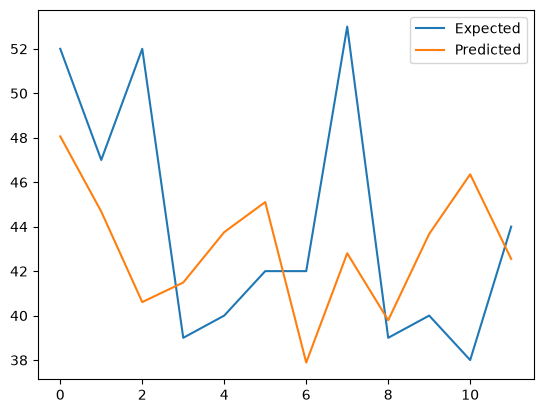

In [35]:
#evaluate

mae, y, yhat = walk_forward_validation(data, 12)
print('MAE: %.3f' % mae)

#plot expected vs predicted
pyplot.plot(y, label = "Expected")
pyplot.plot(yhat, label = "Predicted")
pyplot.legend()
pyplot.show()


In [39]:
#finalise model and make a preiction for monthly births with random forest

from numpy import asarray
from pandas import read_csv
from pandas import DataFrame, concat
from sklearn.ensemble import RandomForestRegressor

#transform a time series datast into a supervised learning dataset
def series_to_supervise1(data, n_in=1, n_out=1, dropnan = True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df=DataFrame(data)
    cols = list()

    #input sequence (t-n, ..., t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(-i))

    #forecast sequence (t, t+1, ..., t_n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))

    #put it al together
    agg = concat(cols, axis = 1)

    #drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg.values

In [41]:
# load the dataset
series = read_csv('daily-total-female-births.csv', header=0, index_col=0)

In [40]:
values = series.values
#transform the time series data into supervised learning

train = series_to_supervise1(values, n_in=6)

In [42]:
print(values[-6:])

[[34]
 [37]
 [52]
 [48]
 [55]
 [50]]


In [43]:
print(train)

[[45. 29. 44. ... 30. 32. 35.]
 [43. 45. 29. ... 31. 30. 32.]
 [38. 43. 45. ... 44. 31. 30.]
 ...
 [48. 52. 37. ... 44. 38. 40.]
 [55. 48. 52. ... 34. 44. 38.]
 [50. 55. 48. ... 37. 34. 44.]]


In [44]:
#split into input and output columns
trainX, trainy = train[:, :-1], train[:, -1]

#fit model
model = RandomForestRegressor(n_estimators=1000)
model.fit(trainX, trainy)

#construct an input for a new prediction
row = values[-6:].flatten()

#make a one step prediction
yhat = model.predict(asarray([row]))
print('Input: %s, Predicted: %.3f' % (row, yhat[0]))

Input: [34 37 52 48 55 50], Predicted: 43.145


In [45]:
series.head()

,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44
